# Генетические алгоритмы: оптимизация нейронной сети на MNIST

Практическая работа по генетическим алгоритмам.

В работе реализованы все три задания в одно решение:

1. **Оптимизация гиперпараметров нейронной сети** с помощью генетического алгоритма.
2. **Многокритериальная оптимизация** по точности и времени обучения методом весовых коэффициентов.
3. **Гибридный генетический алгоритм**, в котором после каждого поколения генетического алгоритма выполняется локальная оптимизация весов нейронной сети градиентным спуском.

Основной набор данных — **MNIST**.

Не используем pip install так все есть в коллабе.

In [1]:
# Импорты

import os
import gc
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display


In [2]:
# Настройки эксперимента

SEED = 42

# Размеры данных для быстрой оценки особей внутри генетического алгоритма.
GA_TRAIN_SIZE = 10000
GA_VALID_SIZE = 2000

# Для гибридного алгоритма используем ещё меньшую выборку,
# поскольку там локальный градиентный спуск выполняется много раз.
HYBRID_TRAIN_SIZE = 6000
HYBRID_VALID_SIZE = 1000

# Фиксированная базовая модель.
BASELINE_PARAMS = {
    "learning_rate": 0.001,
    "num_layers": 2,
    "num_neurons": 128,
}

BASELINE_EPOCHS = 5

# Параметры обычного ГА.
GA_POPULATION_SIZE = 6
GA_GENERATIONS = 4
GA_TOURNAMENT_SIZE = 3
GA_MUTATION_RATE = 0.20
GA_EPOCHS = 2

# Параметры многокритериального ГА.
MULTI_WEIGHT_ACCURACY = 0.70
MULTI_WEIGHT_SPEED = 0.30

# Параметры гибридного ГА.
HYBRID_POPULATION_SIZE = 6
HYBRID_GENERATIONS = 5
HYBRID_TOURNAMENT_SIZE = 3
HYBRID_MUTATION_RATE = 0.02
HYBRID_LOCAL_EPOCHS = 1
HYBRID_LEARNING_RATE = 0.001

OUTPUT_DIR = Path("/content/ga_mnist_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Результаты будут сохранены в:", OUTPUT_DIR)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Результаты будут сохранены в: /content/ga_mnist_results


In [3]:
# Загрузка MNIST

(x_full, y_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_full = x_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Перемешиваем обучающую часть один раз и выделяем validation.
rng = np.random.default_rng(SEED)
indices = np.arange(len(y_full))
rng.shuffle(indices)

valid_indices = indices[:10000]
train_indices = indices[10000:]

x_train = x_full[train_indices]
y_train = y_full[train_indices]

x_valid = x_full[valid_indices]
y_valid = y_full[valid_indices]

x_ga_train = x_train[:GA_TRAIN_SIZE]
y_ga_train = y_train[:GA_TRAIN_SIZE]

x_ga_valid = x_valid[:GA_VALID_SIZE]
y_ga_valid = y_valid[:GA_VALID_SIZE]

x_hybrid_train = x_train[:HYBRID_TRAIN_SIZE]
y_hybrid_train = y_train[:HYBRID_TRAIN_SIZE]

x_hybrid_valid = x_valid[:HYBRID_VALID_SIZE]
y_hybrid_valid = y_valid[:HYBRID_VALID_SIZE]

print("Полная обучающая выборка:", x_train.shape)
print("Validation:", x_valid.shape)
print("Test:", x_test.shape)
print("Подвыборка для ГА:", x_ga_train.shape, x_ga_valid.shape)
print("Подвыборка для гибридного ГА:", x_hybrid_train.shape, x_hybrid_valid.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Полная обучающая выборка: (50000, 28, 28)
Validation: (10000, 28, 28)
Test: (10000, 28, 28)
Подвыборка для ГА: (10000, 28, 28) (2000, 28, 28)
Подвыборка для гибридного ГА: (6000, 28, 28) (1000, 28, 28)


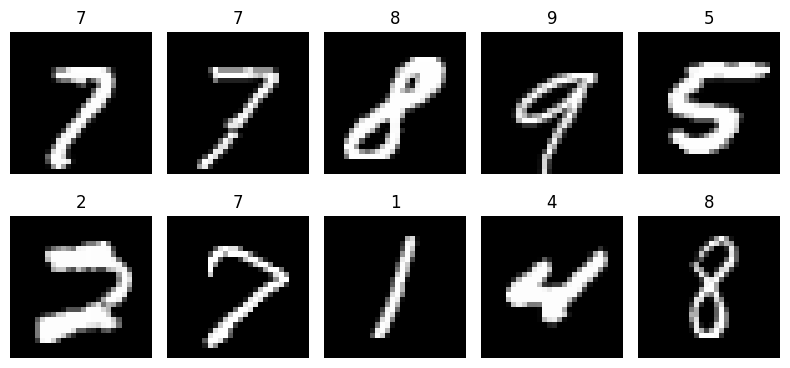

In [4]:
# Визуализация примеров MNIST

plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()


# Задание 1. Оптимизация гиперпараметров нейронной сети

Каждая особь представляет собой хромосому:

`(learning_rate, num_layers, num_neurons)`

Функция приспособленности — точность на validation-выборке.

Диапазоны поиска:

- `learning_rate`: от `0.0001` до `0.01`;
- `num_layers`: от 1 до 3;
- `num_neurons`: от 32 до 256.

Для выбора родителей используется турнир из трёх особей, как в уроке.

In [5]:
# Создание нейронной сети

def build_model(learning_rate, num_layers, num_neurons):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(28, 28)))
    model.add(tf.keras.layers.Flatten())

    for _ in range(num_layers):
        model.add(
            tf.keras.layers.Dense(
                num_neurons,
                activation="relu"
            )
        )

    model.add(tf.keras.layers.Dense(10, activation="softmax"))

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


In [6]:
# Обучение базовой модели с фиксированными гиперпараметрами

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

baseline_model = build_model(**BASELINE_PARAMS)

baseline_start = time.perf_counter()

baseline_history = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=BASELINE_EPOCHS,
    batch_size=128,
    verbose=0,
)

baseline_train_time = time.perf_counter() - baseline_start

baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print("Базовые гиперпараметры:")
print(BASELINE_PARAMS)
print(f"Время обучения: {baseline_train_time:.2f} сек.")
print(f"Точность на тесте: {baseline_test_accuracy:.4f}")


Базовые гиперпараметры:
{'learning_rate': 0.001, 'num_layers': 2, 'num_neurons': 128}
Время обучения: 11.16 сек.
Точность на тесте: 0.9747


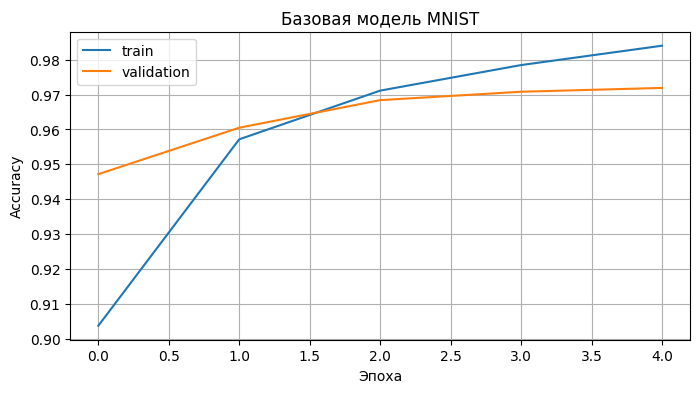

In [7]:
# График обучения базовой модели

plt.figure(figsize=(8, 4))
plt.plot(baseline_history.history["accuracy"], label="train")
plt.plot(baseline_history.history["val_accuracy"], label="validation")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Базовая модель MNIST")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Вспомогательные функции генетического алгоритма

NEURON_VALUES = list(range(32, 257, 32))

def random_learning_rate():
    return 10 ** random.uniform(
        np.log10(1e-4),
        np.log10(1e-2)
    )


def create_individual():
    return (
        random_learning_rate(),
        random.randint(1, 3),
        random.choice(NEURON_VALUES),
    )


def crossover(parent1, parent2):
    child1 = (
        parent1[0] if random.random() < 0.5 else parent2[0],
        parent1[1] if random.random() < 0.5 else parent2[1],
        parent1[2] if random.random() < 0.5 else parent2[2],
    )

    child2 = (
        parent2[0] if random.random() < 0.5 else parent1[0],
        parent2[1] if random.random() < 0.5 else parent1[1],
        parent2[2] if random.random() < 0.5 else parent1[2],
    )

    return child1, child2


def mutate(individual, mutation_rate):
    learning_rate, num_layers, num_neurons = individual

    if random.random() < mutation_rate:
        learning_rate = random_learning_rate()

    if random.random() < mutation_rate:
        num_layers = random.randint(1, 3)

    if random.random() < mutation_rate:
        num_neurons = random.choice(NEURON_VALUES)

    return (
        learning_rate,
        num_layers,
        num_neurons,
    )


def tournament_selection(population, fitness_scores, tournament_size=3):
    participants = random.sample(
        list(zip(population, fitness_scores)),
        tournament_size,
    )

    winner = max(
        participants,
        key=lambda item: item[1]
    )[0]

    return winner


In [9]:
# Функция приспособленности для задания 1

fitness_cache = {}

def evaluate_hyperparameters(
    individual,
    x_train_data,
    y_train_data,
    x_valid_data,
    y_valid_data,
    epochs=GA_EPOCHS,
):
    key = (
        round(individual[0], 10),
        individual[1],
        individual[2],
        len(x_train_data),
        len(x_valid_data),
        epochs,
    )

    if key in fitness_cache:
        return fitness_cache[key]

    learning_rate, num_layers, num_neurons = individual

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_model(
        learning_rate=learning_rate,
        num_layers=num_layers,
        num_neurons=num_neurons,
    )

    start = time.perf_counter()

    history = model.fit(
        x_train_data,
        y_train_data,
        validation_data=(x_valid_data, y_valid_data),
        epochs=epochs,
        batch_size=128,
        verbose=0,
    )

    elapsed = time.perf_counter() - start

    val_accuracy = float(
        max(history.history["val_accuracy"])
    )

    result = {
        "accuracy": val_accuracy,
        "time": elapsed,
    }

    fitness_cache[key] = result

    del model
    gc.collect()

    return result


In [10]:
# Генетический алгоритм для задания 1

def genetic_algorithm_accuracy():
    population = [
        create_individual()
        for _ in range(GA_POPULATION_SIZE)
    ]

    best_individual = None
    best_fitness = -np.inf
    history = []
    records = []

    for generation in range(GA_GENERATIONS):
        fitness_scores = []

        for index, individual in enumerate(population):
            result = evaluate_hyperparameters(
                individual,
                x_ga_train,
                y_ga_train,
                x_ga_valid,
                y_ga_valid,
                epochs=GA_EPOCHS,
            )

            fitness_scores.append(result["accuracy"])

            records.append({
                "generation": generation + 1,
                "individual": index + 1,
                "learning_rate": individual[0],
                "num_layers": individual[1],
                "num_neurons": individual[2],
                "accuracy": result["accuracy"],
                "time": result["time"],
            })

        best_index = int(np.argmax(fitness_scores))
        current_best = population[best_index]
        current_fitness = fitness_scores[best_index]

        if current_fitness > best_fitness:
            best_fitness = current_fitness
            best_individual = current_best

        history.append(best_fitness)

        print(
            f"Поколение {generation + 1}/{GA_GENERATIONS}: "
            f"best accuracy = {current_fitness:.4f}, "
            f"LR = {current_best[0]:.6f}, "
            f"слои = {current_best[1]}, "
            f"нейроны = {current_best[2]}"
        )

        selected_population = [
            tournament_selection(
                population,
                fitness_scores,
                GA_TOURNAMENT_SIZE,
            )
            for _ in range(GA_POPULATION_SIZE)
        ]

        new_population = []

        for i in range(0, GA_POPULATION_SIZE, 2):
            parent1 = selected_population[i]
            parent2 = selected_population[
                (i + 1) % GA_POPULATION_SIZE
            ]

            child1, child2 = crossover(
                parent1,
                parent2,
            )

            child1 = mutate(
                child1,
                GA_MUTATION_RATE,
            )

            child2 = mutate(
                child2,
                GA_MUTATION_RATE,
            )

            new_population.extend([child1, child2])

        population = new_population[:GA_POPULATION_SIZE]

    return (
        best_individual,
        best_fitness,
        history,
        pd.DataFrame(records),
    )


best_params, best_ga_accuracy, ga_history, ga_records = (
    genetic_algorithm_accuracy()
)

print()
print("Лучшие гиперпараметры:")
print(f"Learning rate: {best_params[0]:.6f}")
print(f"Слои: {best_params[1]}")
print(f"Нейроны: {best_params[2]}")
print(f"Лучшая validation accuracy: {best_ga_accuracy:.4f}")


Поколение 1/4: best accuracy = 0.9295, LR = 0.003042, слои = 1, нейроны = 128
Поколение 2/4: best accuracy = 0.9295, LR = 0.003042, слои = 1, нейроны = 128
Поколение 3/4: best accuracy = 0.9320, LR = 0.003042, слои = 1, нейроны = 160
Поколение 4/4: best accuracy = 0.9305, LR = 0.002860, слои = 1, нейроны = 128

Лучшие гиперпараметры:
Learning rate: 0.003042
Слои: 1
Нейроны: 160
Лучшая validation accuracy: 0.9320


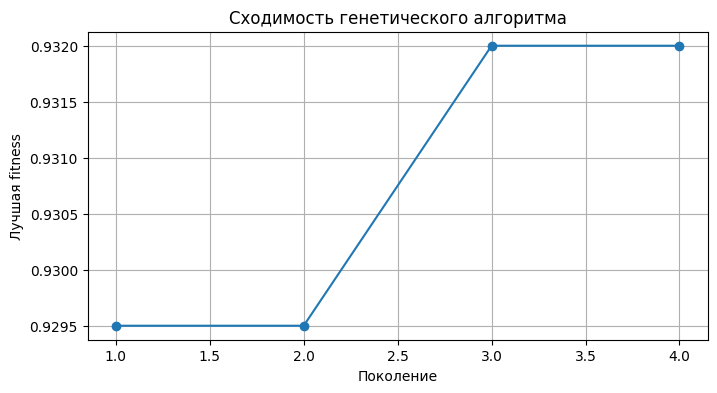

In [11]:
# График сходимости обычного ГА

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(ga_history) + 1),
    ga_history,
    marker="o",
)
plt.xlabel("Поколение")
plt.ylabel("Лучшая fitness")
plt.title("Сходимость генетического алгоритма")
plt.grid(True)
plt.show()


In [12]:
# Финальное обучение модели с найденными гиперпараметрами

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

ga_model = build_model(
    learning_rate=best_params[0],
    num_layers=best_params[1],
    num_neurons=best_params[2],
)

ga_final_start = time.perf_counter()

ga_final_history = ga_model.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=BASELINE_EPOCHS,
    batch_size=128,
    verbose=0,
)

ga_final_train_time = time.perf_counter() - ga_final_start

ga_test_loss, ga_test_accuracy = ga_model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print("Результат после финального обучения:")
print(f"Тестовая accuracy: {ga_test_accuracy:.4f}")
print(f"Время финального обучения: {ga_final_train_time:.2f} сек.")


Результат после финального обучения:
Тестовая accuracy: 0.9757
Время финального обучения: 8.73 сек.


In [13]:
# Сравнение базовой модели и обычного ГА

task1_results = pd.DataFrame([
    {
        "Модель": "Фиксированные гиперпараметры",
        "Learning rate": BASELINE_PARAMS["learning_rate"],
        "Слои": BASELINE_PARAMS["num_layers"],
        "Нейроны": BASELINE_PARAMS["num_neurons"],
        "Test Accuracy": baseline_test_accuracy,
        "Время обучения, сек": baseline_train_time,
    },
    {
        "Модель": "Генетический алгоритм",
        "Learning rate": best_params[0],
        "Слои": best_params[1],
        "Нейроны": best_params[2],
        "Test Accuracy": ga_test_accuracy,
        "Время обучения, сек": ga_final_train_time,
    },
])

display(task1_results)

accuracy_delta = ga_test_accuracy - baseline_test_accuracy

print(
    f"Изменение Test Accuracy после оптимизации ГА: "
    f"{accuracy_delta:+.4f}"
)


,Модель,Learning rate,Слои,Нейроны,Test Accuracy,"Время обучения, сек"
0,Фиксированные гиперпараметры,0.001000,2,128,0.9747,11.158673
1,Генетический алгоритм,0.003042,1,160,0.9757,8.726153


Изменение Test Accuracy после оптимизации ГА: +0.0010


In [14]:
# Сохранение результатов задания 1

ga_records.to_csv(
    OUTPUT_DIR / "task1_ga_history.csv",
    index=False,
)

task1_results.to_csv(
    OUTPUT_DIR / "task1_comparison.csv",
    index=False,
)

ga_model.save(
    OUTPUT_DIR / "mnist_ga_best_model.keras"
)

baseline_model.save(
    OUTPUT_DIR / "mnist_baseline_model.keras"
)


# Задание 2. Многокритериальная оптимизация

Учитываются два критерия:

1. **Accuracy** — нужно максимизировать.
2. **Время обучения** — нужно минимизировать.

Используем метод весовых коэффициентов:

`F = w_accuracy * Accuracy + w_speed * Speed`

где:

- `w_accuracy = 0.70`;
- `w_speed = 0.30`.

Время внутри каждого поколения нормализуется в диапазон `[0, 1]`, после чего преобразуется в показатель скорости: чем меньше время, тем выше `Speed`.

In [15]:
# Многокритериальный генетический алгоритм

def genetic_algorithm_multiobjective():
    population = [
        create_individual()
        for _ in range(GA_POPULATION_SIZE)
    ]

    best_individual = None
    best_fitness = -np.inf
    history = []
    records = []

    for generation in range(GA_GENERATIONS):
        evaluation_results = []

        for index, individual in enumerate(population):
            result = evaluate_hyperparameters(
                individual,
                x_ga_train,
                y_ga_train,
                x_ga_valid,
                y_ga_valid,
                epochs=GA_EPOCHS,
            )

            evaluation_results.append(result)

        accuracies = np.array([
            item["accuracy"]
            for item in evaluation_results
        ])

        times = np.array([
            item["time"]
            for item in evaluation_results
        ])

        # Accuracy уже находится в диапазоне [0, 1].
        accuracy_score = accuracies

        # Нормируем время внутри текущего поколения.
        time_min = times.min()
        time_max = times.max()

        if np.isclose(time_max, time_min):
            speed_score = np.ones_like(times)
        else:
            speed_score = (
                (time_max - times)
                / (time_max - time_min)
            )

        weighted_scores = (
            MULTI_WEIGHT_ACCURACY * accuracy_score
            + MULTI_WEIGHT_SPEED * speed_score
        )

        for index, individual in enumerate(population):
            records.append({
                "generation": generation + 1,
                "individual": index + 1,
                "learning_rate": individual[0],
                "num_layers": individual[1],
                "num_neurons": individual[2],
                "accuracy": accuracies[index],
                "time": times[index],
                "speed_score": speed_score[index],
                "weighted_fitness": weighted_scores[index],
            })

        best_index = int(np.argmax(weighted_scores))
        current_best = population[best_index]
        current_fitness = weighted_scores[best_index]

        if current_fitness > best_fitness:
            best_fitness = current_fitness
            best_individual = current_best

        history.append(best_fitness)

        print(
            f"Поколение {generation + 1}/{GA_GENERATIONS}: "
            f"fitness = {current_fitness:.4f}, "
            f"accuracy = {accuracies[best_index]:.4f}, "
            f"time = {times[best_index]:.2f} сек."
        )

        selected_population = [
            tournament_selection(
                population,
                weighted_scores.tolist(),
                GA_TOURNAMENT_SIZE,
            )
            for _ in range(GA_POPULATION_SIZE)
        ]

        new_population = []

        for i in range(0, GA_POPULATION_SIZE, 2):
            parent1 = selected_population[i]
            parent2 = selected_population[
                (i + 1) % GA_POPULATION_SIZE
            ]

            child1, child2 = crossover(
                parent1,
                parent2,
            )

            child1 = mutate(
                child1,
                GA_MUTATION_RATE,
            )

            child2 = mutate(
                child2,
                GA_MUTATION_RATE,
            )

            new_population.extend([child1, child2])

        population = new_population[:GA_POPULATION_SIZE]

    return (
        best_individual,
        best_fitness,
        history,
        pd.DataFrame(records),
    )


multi_best_params, multi_best_fitness, multi_history, multi_records = (
    genetic_algorithm_multiobjective()
)

print()
print("Лучшие гиперпараметры многокритериального ГА:")
print(f"Learning rate: {multi_best_params[0]:.6f}")
print(f"Слои: {multi_best_params[1]}")
print(f"Нейроны: {multi_best_params[2]}")
print(f"Лучший взвешенный fitness: {multi_best_fitness:.4f}")


Поколение 1/4: fitness = 0.8838, accuracy = 0.8340, time = 2.86 сек.
Поколение 2/4: fitness = 0.9549, accuracy = 0.9355, time = 2.82 сек.
Поколение 3/4: fitness = 0.9549, accuracy = 0.9355, time = 2.82 сек.
Поколение 4/4: fitness = 0.9549, accuracy = 0.9355, time = 2.82 сек.

Лучшие гиперпараметры многокритериального ГА:
Learning rate: 0.003633
Слои: 1
Нейроны: 160
Лучший взвешенный fitness: 0.9549


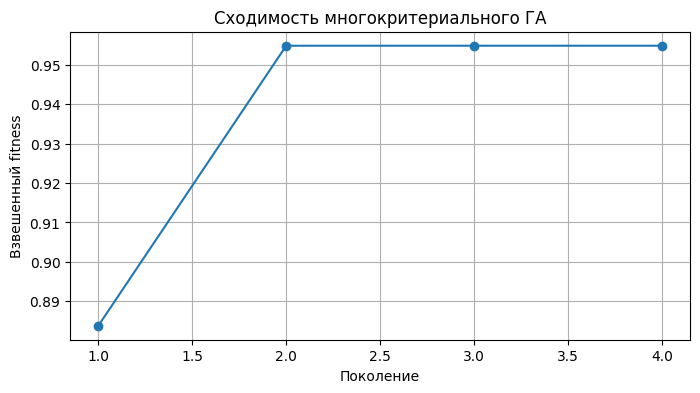

In [16]:
# График сходимости многокритериального ГА

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(multi_history) + 1),
    multi_history,
    marker="o",
)
plt.xlabel("Поколение")
plt.ylabel("Взвешенный fitness")
plt.title("Сходимость многокритериального ГА")
plt.grid(True)
plt.show()


In [17]:
# Финальное обучение многокритериально найденной модели

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

multi_model = build_model(
    learning_rate=multi_best_params[0],
    num_layers=multi_best_params[1],
    num_neurons=multi_best_params[2],
)

multi_final_start = time.perf_counter()

multi_model.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=BASELINE_EPOCHS,
    batch_size=128,
    verbose=0,
)

multi_final_train_time = time.perf_counter() - multi_final_start

multi_test_loss, multi_test_accuracy = multi_model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print(f"Test Accuracy: {multi_test_accuracy:.4f}")
print(f"Время финального обучения: {multi_final_train_time:.2f} сек.")


Test Accuracy: 0.9745
Время финального обучения: 9.32 сек.


In [18]:
# Сравнение результатов заданий 1 и 2

task2_results = pd.DataFrame([
    {
        "Модель": "Фиксированные гиперпараметры",
        "Test Accuracy": baseline_test_accuracy,
        "Время обучения, сек": baseline_train_time,
    },
    {
        "Модель": "Обычный ГА",
        "Test Accuracy": ga_test_accuracy,
        "Время обучения, сек": ga_final_train_time,
    },
    {
        "Модель": "Многокритериальный ГА",
        "Test Accuracy": multi_test_accuracy,
        "Время обучения, сек": multi_final_train_time,
    },
])

display(task2_results)


,Модель,Test Accuracy,"Время обучения, сек"
0,Фиксированные гиперпараметры,0.9747,11.158673
1,Обычный ГА,0.9757,8.726153
2,Многокритериальный ГА,0.9745,9.320398


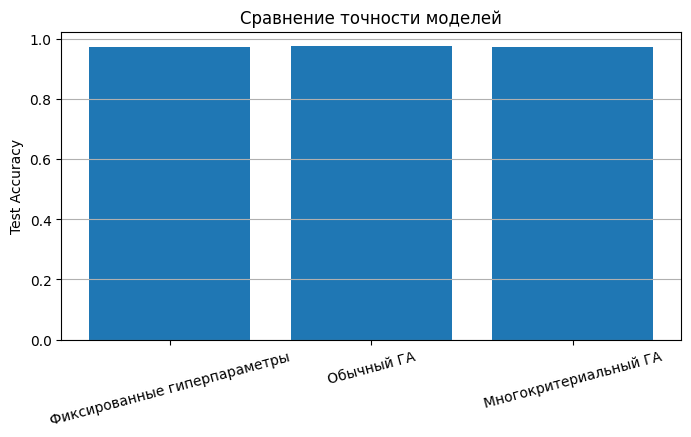

In [19]:
# Сохранение результатов задания 2

multi_records.to_csv(
    OUTPUT_DIR / "task2_multiobjective_history.csv",
    index=False,
)

task2_results.to_csv(
    OUTPUT_DIR / "task2_comparison.csv",
    index=False,
)

multi_model.save(
    OUTPUT_DIR / "mnist_multiobjective_model.keras"
)

plt.figure(figsize=(8, 4))
plt.bar(
    task2_results["Модель"],
    task2_results["Test Accuracy"],
)
plt.ylabel("Test Accuracy")
plt.title("Сравнение точности моделей")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()


# Задание 3. Гибридный генетический алгоритм

Здесь генетический алгоритм работает уже не с гиперпараметрами, а с **весами фиксированной нейронной сети**.

Хромосома представляет собой вектор весов сети.

На каждом поколении:

1. оцениваем особей;
2. выполняем турнирный отбор;
3. создаём потомков кроссовером;
4. применяем мутацию;
5. после завершения генетического шага выполняем локальную оптимизацию весов потомков методом градиентного спуска;
6. результат локальной оптимизации становится основой следующего поколения.

Так объединяются глобальный поиск генетического алгоритма и локальный поиск градиентного спуска.

In [20]:
# Фиксированная архитектура для гибридного ГА

HYBRID_NEURONS = 32

def build_hybrid_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(
            HYBRID_NEURONS,
            activation="relu",
        ),
        tf.keras.layers.Dense(
            10,
            activation="softmax",
        ),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=HYBRID_LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


template_model = build_hybrid_model()
template_weights = template_model.get_weights()
weight_shapes = [weights.shape for weights in template_weights]
weight_sizes = [weights.size for weights in template_weights]
TOTAL_WEIGHT_COUNT = sum(weight_sizes)

print("Количество генов в хромосоме:", TOTAL_WEIGHT_COUNT)
print("Формы массивов весов:", weight_shapes)


Количество генов в хромосоме: 25450
Формы массивов весов: [(784, 32), (32,), (32, 10), (10,)]


In [21]:
# Преобразование весов модели в хромосому и обратно

def weights_to_vector(weights):
    return np.concatenate([
        weight.reshape(-1)
        for weight in weights
    ]).astype("float32")


def vector_to_weights(vector):
    weights = []
    start = 0

    for shape, size in zip(
        weight_shapes,
        weight_sizes,
    ):
        part = vector[
            start:start + size
        ]

        weights.append(
            part.reshape(shape).astype("float32")
        )

        start += size

    return weights


def create_weight_individual():
    model = build_hybrid_model()
    weights = model.get_weights()

    vector = weights_to_vector(weights)

    # Небольшое случайное отличие между особями.
    vector = vector + np.random.normal(
        loc=0.0,
        scale=0.03,
        size=vector.shape,
    ).astype("float32")

    del model
    gc.collect()

    return vector


def weight_crossover(parent1, parent2):
    point = random.randint(
        1,
        len(parent1) - 1,
    )

    child1 = np.concatenate([
        parent1[:point],
        parent2[point:],
    ])

    child2 = np.concatenate([
        parent2[:point],
        parent1[point:],
    ])

    return (
        child1.astype("float32"),
        child2.astype("float32"),
    )


def weight_mutation(vector, mutation_rate):
    child = vector.copy()

    mask = np.random.random(
        size=child.shape
    ) < mutation_rate

    if np.any(mask):
        child[mask] += np.random.normal(
            loc=0.0,
            scale=0.02,
            size=mask.sum(),
        ).astype("float32")

    return child


In [22]:
# Оценка хромосомы весов

def evaluate_weight_individual(
    vector,
    x_data,
    y_data,
):
    tf.keras.backend.clear_session()

    model = build_hybrid_model()
    model.set_weights(
        vector_to_weights(vector)
    )

    _, accuracy = model.evaluate(
        x_data,
        y_data,
        verbose=0,
    )

    del model
    gc.collect()

    return float(accuracy)


In [23]:
# Локальная оптимизация весов градиентным спуском

def local_gradient_optimization(vector):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_hybrid_model()

    model.set_weights(
        vector_to_weights(vector)
    )

    start = time.perf_counter()

    history = model.fit(
        x_hybrid_train,
        y_hybrid_train,
        validation_data=(
            x_hybrid_valid,
            y_hybrid_valid,
        ),
        epochs=HYBRID_LOCAL_EPOCHS,
        batch_size=128,
        verbose=0,
    )

    elapsed = time.perf_counter() - start

    new_vector = weights_to_vector(
        model.get_weights()
    )

    accuracy = float(
        max(history.history["val_accuracy"])
    )

    del model
    gc.collect()

    return new_vector, accuracy, elapsed


In [24]:
# Гибридный генетический алгоритм

def hybrid_genetic_algorithm():
    population = [
        create_weight_individual()
        for _ in range(HYBRID_POPULATION_SIZE)
    ]

    # Первичная оценка случайной популяции.
    fitness_scores = [
        evaluate_weight_individual(
            individual,
            x_hybrid_valid,
            y_hybrid_valid,
        )
        for individual in population
    ]

    best_vector = population[
        int(np.argmax(fitness_scores))
    ].copy()

    best_fitness = max(fitness_scores)

    history = [
        best_fitness
    ]

    records = []

    for generation in range(HYBRID_GENERATIONS):
        selected_population = [
            tournament_selection(
                population,
                fitness_scores,
                HYBRID_TOURNAMENT_SIZE,
            )
            for _ in range(HYBRID_POPULATION_SIZE)
        ]

        new_population = []

        for i in range(
            0,
            HYBRID_POPULATION_SIZE,
            2,
        ):
            parent1 = selected_population[i]
            parent2 = selected_population[
                (i + 1) % HYBRID_POPULATION_SIZE
            ]

            child1, child2 = weight_crossover(
                parent1,
                parent2,
            )

            child1 = weight_mutation(
                child1,
                HYBRID_MUTATION_RATE,
            )

            child2 = weight_mutation(
                child2,
                HYBRID_MUTATION_RATE,
            )

            new_population.extend([
                child1,
                child2,
            ])

        new_population = new_population[
            :HYBRID_POPULATION_SIZE
        ]

        # Гибридная часть:
        # после генетического шага каждый потомок
        # локально оптимизируется градиентным спуском.
        optimized_population = []
        optimized_fitness = []

        for index, child in enumerate(
            new_population
        ):
            optimized_child, accuracy, elapsed = (
                local_gradient_optimization(child)
            )

            optimized_population.append(
                optimized_child
            )

            optimized_fitness.append(
                accuracy
            )

            records.append({
                "generation": generation + 1,
                "individual": index + 1,
                "validation_accuracy": accuracy,
                "local_train_time": elapsed,
            })

        population = optimized_population
        fitness_scores = optimized_fitness

        current_best_index = int(
            np.argmax(fitness_scores)
        )

        current_best_fitness = (
            fitness_scores[current_best_index]
        )

        if current_best_fitness > best_fitness:
            best_fitness = current_best_fitness
            best_vector = population[
                current_best_index
            ].copy()

        history.append(best_fitness)

        print(
            f"Поколение {generation + 1}/"
            f"{HYBRID_GENERATIONS}: "
            f"best validation accuracy = "
            f"{current_best_fitness:.4f}"
        )

    return (
        best_vector,
        best_fitness,
        history,
        pd.DataFrame(records),
    )


hybrid_best_vector, hybrid_best_accuracy, hybrid_history, hybrid_records = (
    hybrid_genetic_algorithm()
)

print()
print(
    "Лучшая validation accuracy гибридного ГА:",
    f"{hybrid_best_accuracy:.4f}",
)


Поколение 1/5: best validation accuracy = 0.7920
Поколение 2/5: best validation accuracy = 0.8730
Поколение 3/5: best validation accuracy = 0.8870
Поколение 4/5: best validation accuracy = 0.8980
Поколение 5/5: best validation accuracy = 0.9040

Лучшая validation accuracy гибридного ГА: 0.9040


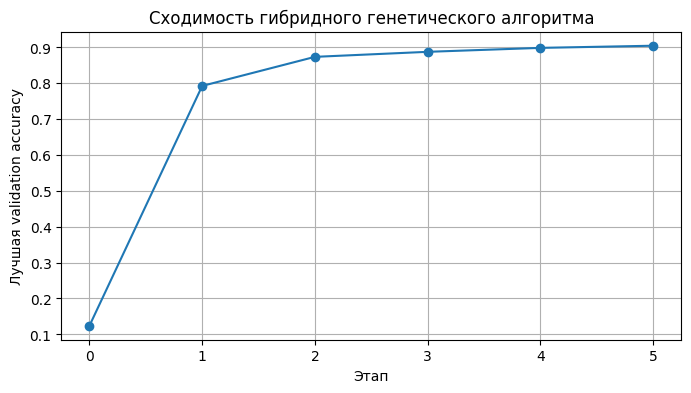

In [25]:
# График работы гибридного ГА

plt.figure(figsize=(8, 4))
plt.plot(
    range(len(hybrid_history)),
    hybrid_history,
    marker="o",
)
plt.xlabel("Этап")
plt.ylabel("Лучшая validation accuracy")
plt.title("Сходимость гибридного генетического алгоритма")
plt.grid(True)
plt.show()


In [26]:
# Финальная оценка лучшей хромосомы гибридного ГА

tf.keras.backend.clear_session()

hybrid_final_model = build_hybrid_model()
hybrid_final_model.set_weights(
    vector_to_weights(hybrid_best_vector)
)

hybrid_test_loss, hybrid_test_accuracy = (
    hybrid_final_model.evaluate(
        x_test,
        y_test,
        verbose=0,
    )
)

print(
    f"Test Accuracy гибридного ГА: "
    f"{hybrid_test_accuracy:.4f}"
)


Test Accuracy гибридного ГА: 0.9118


,Подход,Test Accuracy,"Время обучения, сек","Время финального обучения, сек"
0,Фиксированные гиперпараметры,0.9747,11.158673,NaN
1,ГА: оптимизация гиперпараметров,0.9757,NaN,8.726153
2,Многокритериальный ГА,0.9745,NaN,9.320398
3,Гибридный ГА + градиентный спуск,0.9118,NaN,NaN


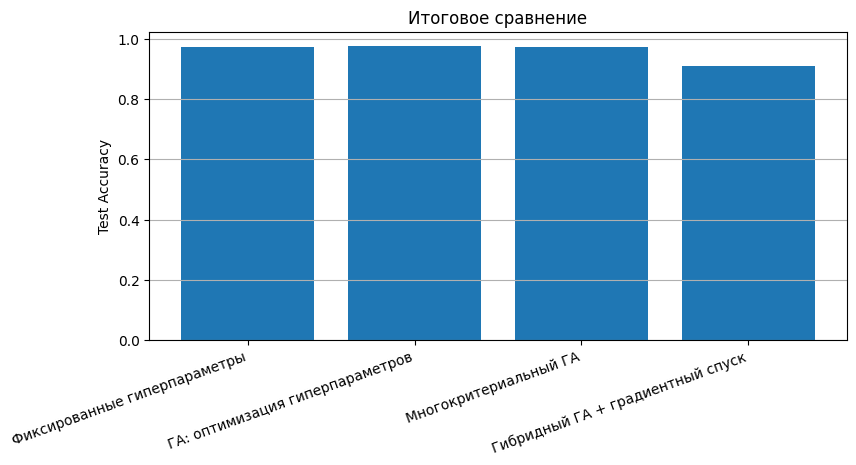

In [27]:
# Итоговое сравнение всех подходов

final_results = pd.DataFrame([
    {
        "Подход": "Фиксированные гиперпараметры",
        "Test Accuracy": baseline_test_accuracy,
        "Время обучения, сек": baseline_train_time,
    },
    {
        "Подход": "ГА: оптимизация гиперпараметров",
        "Test Accuracy": ga_test_accuracy,
        "Время финального обучения, сек": ga_final_train_time,
    },
    {
        "Подход": "Многокритериальный ГА",
        "Test Accuracy": multi_test_accuracy,
        "Время финального обучения, сек": multi_final_train_time,
    },
    {
        "Подход": "Гибридный ГА + градиентный спуск",
        "Test Accuracy": hybrid_test_accuracy,
    },
])

display(final_results)

plt.figure(figsize=(9, 4))
plt.bar(
    final_results["Подход"],
    final_results["Test Accuracy"],
)
plt.ylabel("Test Accuracy")
plt.title("Итоговое сравнение")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.show()


In [28]:
# Автоматическая заготовка вывода

print("ВЫВОДЫ")
print()
print(
    f"1. Базовая модель получила Test Accuracy = "
    f"{baseline_test_accuracy:.4f}."
)
print(
    f"2. Обычный генетический алгоритм нашёл гиперпараметры "
    f"(LR={best_params[0]:.6f}, слои={best_params[1]}, "
    f"нейроны={best_params[2]}) и получил Test Accuracy = "
    f"{ga_test_accuracy:.4f}."
)
print(
    f"3. Изменение точности относительно базовой модели: "
    f"{ga_test_accuracy - baseline_test_accuracy:+.4f}."
)
print(
    f"4. Многокритериальный ГА использовал взвешенную функцию "
    f"из точности и скорости обучения "
    f"({MULTI_WEIGHT_ACCURACY:.0%} / {MULTI_WEIGHT_SPEED:.0%})."
)
print(
    f"5. Многокритериальная модель получила Test Accuracy = "
    f"{multi_test_accuracy:.4f}."
)
print(
    f"6. Гибридный ГА с локальным градиентным спуском "
    f"получил Test Accuracy = {hybrid_test_accuracy:.4f}."
)
print()
print(
    "При интерпретации результатов важно учитывать, что "
    "генетический алгоритм требует многократного обучения "
    "нейронных сетей, поэтому поиск гиперпараметров сам по себе "
    "дороже одного фиксированного запуска."
)


ВЫВОДЫ

1. Базовая модель получила Test Accuracy = 0.9747.
2. Обычный генетический алгоритм нашёл гиперпараметры (LR=0.003042, слои=1, нейроны=160) и получил Test Accuracy = 0.9757.
3. Изменение точности относительно базовой модели: +0.0010.
4. Многокритериальный ГА использовал взвешенную функцию из точности и скорости обучения (70% / 30%).
5. Многокритериальная модель получила Test Accuracy = 0.9745.
6. Гибридный ГА с локальным градиентным спуском получил Test Accuracy = 0.9118.

При интерпретации результатов важно учитывать, что генетический алгоритм требует многократного обучения нейронных сетей, поэтому поиск гиперпараметров сам по себе дороже одного фиксированного запуска.


In [29]:
# Сохранение всех результатов

multi_records.to_csv(
    OUTPUT_DIR / "task2_multiobjective_history.csv",
    index=False,
)

hybrid_records.to_csv(
    OUTPUT_DIR / "task3_hybrid_history.csv",
    index=False,
)

final_results.to_csv(
    OUTPUT_DIR / "final_results.csv",
    index=False,
)

hybrid_final_model.save_weights(
    OUTPUT_DIR / "hybrid_best.weights.h5"
)

print("Все основные результаты сохранены в:", OUTPUT_DIR)


Все основные результаты сохранены в: /content/ga_mnist_results
